# Person Filter Audit


This notebook answers three questions:
1. How much data is retained after filtering to `person`?
2. How do class counts and box geometry change before vs after filtering?
3. For KITTI train, do the filtered annotations align with the same image stems as the original person-like labels?

Datasets covered:
- `D:/AOC/datasets/coco2017-origin`
- `D:/AOC/datasets/coco2017-filtered-coco`
- `D:/AOC/datasets/kitti-yolo`
- `D:/AOC/datasets/kitti-filtered-coco`


In [1]:
from pathlib import Path
import json
import random
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 120)


In [2]:
ROOT = Path(r'D:/AOC')

COCO_ORIGIN_ROOT = ROOT / 'datasets' / 'coco2017-origin'
COCO_FILTERED_ROOT = ROOT / 'datasets' / 'coco2017-filtered-coco'
KITTI_YOLO_ROOT = ROOT / 'datasets' / 'kitti-yolo'
KITTI_FILTERED_ROOT = ROOT / 'datasets' / 'kitti-filtered-coco'

COCO_ORIGIN_ANN = {
    'train': COCO_ORIGIN_ROOT / 'train' / 'labels.json',
    'validation': COCO_ORIGIN_ROOT / 'validation' / 'labels.json',
    'test': COCO_ORIGIN_ROOT / 'test' / 'labels.json',
}
COCO_FILTERED_ANN = {
    'train': COCO_FILTERED_ROOT / 'annotations' / 'instances_train.json',
    'val': COCO_FILTERED_ROOT / 'annotations' / 'instances_val.json',
}
KITTI_FILTERED_ANN = {
    'train': KITTI_FILTERED_ROOT / 'annotations' / 'instances_train.json',
    'val': KITTI_FILTERED_ROOT / 'annotations' / 'instances_val.json',
}

KITTI_CLASS_MAP = {
    0: 'car',
    1: 'van',
    2: 'truck',
    3: 'pedestrian',
    4: 'Person_sitting',
    5: 'cyclist',
    6: 'tram',
    7: 'misc',
}
PERSON_LIKE_IDS = {3, 4, 5}
ALL_CLASS_IDS = set(KITTI_CLASS_MAP)
IMAGE_SUFFIXES = ['.png', '.jpg', '.jpeg', '.bmp', '.webp']

SAMPLE_SEED = 11
N_SAMPLES = 6
MANUAL_STEMS = []

print('COCO origin root   :', COCO_ORIGIN_ROOT)
print('COCO filtered root :', COCO_FILTERED_ROOT)
print('KITTI YOLO root    :', KITTI_YOLO_ROOT)
print('KITTI filtered root:', KITTI_FILTERED_ROOT)


COCO origin root   : D:\AOC\datasets\coco2017-origin
COCO filtered root : D:\AOC\datasets\coco2017-filtered-coco
KITTI YOLO root    : D:\AOC\datasets\kitti-yolo
KITTI filtered root: D:\AOC\datasets\kitti-filtered-coco


In [3]:
def split_key(name: str) -> str:
    return {'validation': 'val', 'valid': 'val'}.get(name, name)


def load_coco(path: Path) -> dict:
    with path.open('r', encoding='utf-8') as handle:
        return json.load(handle)


def safe_div(num, den):
    if den in (0, None):
        return np.nan
    return num / den


def coco_person_ids(coco: dict, person_name: str = 'person') -> set:
    return {category['id'] for category in coco.get('categories', []) if category.get('name') == person_name}


def coco_split_summary(coco: dict, dataset_label: str, split_label: str, person_name: str = 'person') -> dict:
    images = coco.get('images', [])
    annotations = coco.get('annotations', [])
    person_ids = coco_person_ids(coco, person_name)
    person_annotations = [ann for ann in annotations if ann.get('category_id') in person_ids]
    image_ids_with_person = {ann.get('image_id') for ann in person_annotations}
    return {
        'dataset': dataset_label,
        'split': split_label,
        'split_key': split_key(split_label),
        'num_categories': len(coco.get('categories', [])),
        'num_images': len(images),
        'num_annotations': len(annotations),
        'person_category_ids': sorted(person_ids),
        'person_annotations': len(person_annotations),
        'images_with_person': len(image_ids_with_person),
    }


def coco_annotations_df(coco: dict, dataset_label: str, split_label: str, ann_filter=None) -> pd.DataFrame:
    image_lookup = {
        img.get('id'): (img.get('width'), img.get('height'), img.get('file_name'))
        for img in coco.get('images', [])
    }
    rows = []
    for ann in coco.get('annotations', []):
        if ann_filter is not None and not ann_filter(ann):
            continue
        bbox = ann.get('bbox', [np.nan, np.nan, np.nan, np.nan])
        bw = float(bbox[2]) if len(bbox) > 2 else np.nan
        bh = float(bbox[3]) if len(bbox) > 3 else np.nan
        iw, ih, fname = image_lookup.get(ann.get('image_id'), (np.nan, np.nan, None))
        iw = float(iw) if iw is not None else np.nan
        ih = float(ih) if ih is not None else np.nan
        area = float(ann['area']) if ann.get('area') is not None else bw * bh
        rows.append({
            'dataset': dataset_label,
            'split': split_label,
            'image_id': ann.get('image_id'),
            'annotation_id': ann.get('id'),
            'category_id': ann.get('category_id'),
            'file_name': fname,
            'bbox_w': bw,
            'bbox_h': bh,
            'bbox_area': area,
            'image_w': iw,
            'image_h': ih,
            'area_ratio': safe_div(area, iw * ih) if not (np.isnan(iw) or np.isnan(ih)) else np.nan,
            'aspect_ratio': safe_div(bw, bh),
        })
    return pd.DataFrame(rows)


def coco_class_counts(coco: dict) -> pd.DataFrame:
    category_lookup = {category['id']: category.get('name', str(category['id'])) for category in coco.get('categories', [])}
    counts = pd.Series([ann.get('category_id') for ann in coco.get('annotations', [])]).value_counts().rename_axis('category_id').reset_index(name='count')
    counts['category_name'] = counts['category_id'].map(category_lookup).fillna('unknown')
    return counts[['category_id', 'category_name', 'count']]


def count_images(images_dir: Path) -> int:
    return sum(1 for path in images_dir.glob('*') if path.is_file() and path.suffix.lower() in IMAGE_SUFFIXES)


def parse_kitti_yolo_split(label_dir: Path, split_label: str, class_map: dict) -> tuple[pd.DataFrame, int]:
    rows = []
    label_files = sorted(label_dir.glob('*.txt'))
    for label_file in label_files:
        text = label_file.read_text(encoding='utf-8', errors='ignore')
        for line in text.splitlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            try:
                class_id = int(float(parts[0]))
                xc, yc, bw, bh = map(float, parts[1:5])
            except ValueError:
                continue
            rows.append({
                'split': split_label,
                'image_stem': label_file.stem,
                'class_id': class_id,
                'class_name': class_map.get(class_id, f'class_{class_id}'),
                'x_center': xc,
                'y_center': yc,
                'bbox_w_norm': bw,
                'bbox_h_norm': bh,
                'area_ratio': bw * bh,
                'aspect_ratio': safe_div(bw, bh),
                'is_person_like': class_id in PERSON_LIKE_IDS,
            })
    return pd.DataFrame(rows), len(label_files)


def parse_yolo_line(line: str):
    parts = line.split()
    if len(parts) < 5:
        return None
    try:
        class_id = int(float(parts[0]))
        xc, yc, bw, bh = map(float, parts[1:5])
    except ValueError:
        return None
    return class_id, xc, yc, bw, bh


def find_image_for_stem(images_dir: Path, stem: str):
    for suffix in IMAGE_SUFFIXES:
        candidate = images_dir / f'{stem}{suffix}'
        if candidate.exists():
            return candidate
    return None


def load_filtered_index(ann_path: Path, filtered_root: Path, person_cat_id: int = 1):
    coco = load_coco(ann_path)
    image_by_id = {image['id']: image for image in coco.get('images', [])}
    image_path_by_stem = {}
    boxes_by_stem = defaultdict(list)

    for image in coco.get('images', []):
        stem = Path(str(image.get('file_name', ''))).stem
        direct = filtered_root / str(image.get('file_name', ''))
        fallback = filtered_root / 'images' / 'train' / Path(str(image.get('file_name', ''))).name
        image_path_by_stem[stem] = direct if direct.exists() else fallback

    for ann in coco.get('annotations', []):
        if ann.get('category_id') != person_cat_id:
            continue
        image = image_by_id.get(ann.get('image_id'))
        if not image:
            continue
        stem = Path(str(image.get('file_name', ''))).stem
        x, y, w, h = ann.get('bbox', [0, 0, 0, 0])
        boxes_by_stem[stem].append((1, x, y, x + w, y + h))

    return image_path_by_stem, boxes_by_stem


def collect_origin_stems_with_class(label_dir: Path, class_ids: set[int]) -> set[str]:
    stems = set()
    for label_file in label_dir.glob('*.txt'):
        text = label_file.read_text(encoding='utf-8', errors='ignore')
        for line in text.splitlines():
            parsed = parse_yolo_line(line.strip())
            if parsed is None:
                continue
            class_id = parsed[0]
            if class_id in class_ids:
                stems.add(label_file.stem)
                break
    return stems


def read_origin_boxes(labels_dir: Path, images_dir: Path, stem: str, class_ids: set[int]):
    label_file = labels_dir / f'{stem}.txt'
    image_path = find_image_for_stem(images_dir, stem)
    if not label_file.exists() or image_path is None:
        return None, []

    image = Image.open(image_path).convert('RGB')
    width, height = image.size
    boxes = []
    for line in label_file.read_text(encoding='utf-8', errors='ignore').splitlines():
        parsed = parse_yolo_line(line.strip())
        if parsed is None:
            continue
        class_id, xc, yc, bw, bh = parsed
        if class_id not in class_ids:
            continue
        x1 = (xc - bw / 2) * width
        y1 = (yc - bh / 2) * height
        x2 = (xc + bw / 2) * width
        y2 = (yc + bh / 2) * height
        boxes.append((class_id, x1, y1, x2, y2))
    return image, boxes


def draw_boxes(image: Image.Image, boxes, default_color='yellow', class_colored=False) -> Image.Image:
    rendered = image.copy()
    painter = ImageDraw.Draw(rendered)
    class_colors = {
        0: 'cyan',
        1: 'orange',
        2: 'lime',
        3: 'yellow',
        4: 'magenta',
        5: 'red',
        6: 'white',
        7: 'deepskyblue',
    }
    for class_id, x1, y1, x2, y2 in boxes:
        color = class_colors.get(class_id, default_color) if class_colored else default_color
        painter.rectangle([x1, y1, x2, y2], outline=color, width=2)
    return rendered


def build_origin_view(images_dir: Path, labels_dir: Path, stem: str, class_ids: set[int], class_colored: bool = False):
    image, boxes = read_origin_boxes(labels_dir, images_dir, stem, class_ids)
    if image is None:
        raise FileNotFoundError(f'Missing origin image or label for stem {stem}')
    rendered = draw_boxes(image, boxes, default_color='yellow', class_colored=class_colored)
    return rendered, len(boxes)


def build_filtered_view(filtered_paths: dict, filtered_boxes: dict, stem: str):
    image_path = filtered_paths.get(stem)
    if image_path is None or not image_path.exists():
        raise FileNotFoundError(f'Missing filtered image for stem {stem}')
    image = Image.open(image_path).convert('RGB')
    boxes = filtered_boxes.get(stem, [])
    rendered = draw_boxes(image, boxes, default_color='red', class_colored=False)
    return rendered, len(boxes)


def plot_strict_matrix(stems, origin_images_dir: Path, origin_labels_dir: Path, filtered_paths: dict, filtered_boxes: dict):
    rows = len(stems)
    fig, axes = plt.subplots(rows, 3, figsize=(18, 4.5 * rows))
    if rows == 1:
        axes = np.array([axes])

    headers = [
        'Origin all classes',
        'Origin person-like only (3/4/5)',
        'Filtered person only',
    ]

    for row, stem in enumerate(stems):
        img_all, n_all = build_origin_view(origin_images_dir, origin_labels_dir, stem, ALL_CLASS_IDS, class_colored=True)
        img_person, n_person = build_origin_view(origin_images_dir, origin_labels_dir, stem, PERSON_LIKE_IDS, class_colored=False)
        img_filtered, n_filtered = build_filtered_view(filtered_paths, filtered_boxes, stem)

        for col, (img, nbox, title) in enumerate([
            (img_all, n_all, headers[0]),
            (img_person, n_person, headers[1]),
            (img_filtered, n_filtered, headers[2]),
        ]):
            axes[row, col].imshow(img)
            axes[row, col].set_title(f'{title} {stem} | {nbox} boxes')
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()


## Load All Data

This section loads the four dataset variants once and builds the core summary tables used throughout the notebook.

In [4]:
coco_origin = {split: load_coco(path) for split, path in COCO_ORIGIN_ANN.items()}
coco_filtered = {split: load_coco(path) for split, path in COCO_FILTERED_ANN.items()}

coco_before_summary = pd.DataFrame([
    coco_split_summary(coco_origin[split], 'coco2017-origin', split)
    for split in ['train', 'validation', 'test']
])
coco_after_summary = pd.DataFrame([
    coco_split_summary(coco_filtered[split], 'coco2017-filtered-coco', split)
    for split in ['train', 'val']
])

kitti_before_parts = {}
kitti_before_label_files = {}
for split in ['train', 'val']:
    part, num_label_files = parse_kitti_yolo_split(KITTI_YOLO_ROOT / 'labels' / split, split, KITTI_CLASS_MAP)
    kitti_before_parts[split] = part
    kitti_before_label_files[split] = num_label_files
kitti_before_df = pd.concat([kitti_before_parts['train'], kitti_before_parts['val']], ignore_index=True)

kitti_before_summary = pd.DataFrame([
    {
        'dataset': 'kitti-yolo',
        'split': split,
        'num_images': count_images(KITTI_YOLO_ROOT / 'images' / split),
        'num_label_files': kitti_before_label_files[split],
        'num_annotations': int(len(kitti_before_parts[split])),
        'person_category_ids': sorted(PERSON_LIKE_IDS),
        'person_like_annotations': int(kitti_before_parts[split]['is_person_like'].sum()),
        'images_with_person_like': int(kitti_before_parts[split].loc[kitti_before_parts[split]['is_person_like'], 'image_stem'].nunique()),
    }
    for split in ['train', 'val']
])

kitti_after = {split: load_coco(path) for split, path in KITTI_FILTERED_ANN.items()}
kitti_after_summary = pd.DataFrame([
    coco_split_summary(kitti_after[split], 'kitti-filtered-coco', split, person_name='person')
    for split in ['train', 'val']
])

display(Markdown('### COCO before filtering'))
display(coco_before_summary)
display(Markdown('### COCO after filtering'))
display(coco_after_summary)
display(Markdown('### KITTI before filtering'))
display(kitti_before_summary)
display(Markdown('### KITTI after filtering'))
display(kitti_after_summary)

print('COCO note: the origin test split has no annotations, so person-retention analysis is only meaningful for train and validation.')


### COCO before filtering

,dataset,split,split_key,num_categories,num_images,num_annotations,person_category_ids,person_annotations,images_with_person
0,coco2017-origin,train,train,80,118287,860001,[1],262465,64115
1,coco2017-origin,validation,val,80,5000,36781,[1],11004,2693
2,coco2017-origin,test,test,80,40670,0,[1],0,0


### COCO after filtering

,dataset,split,split_key,num_categories,num_images,num_annotations,person_category_ids,person_annotations,images_with_person
0,coco2017-filtered-coco,train,train,1,64115,262465,[1],262465,64115
1,coco2017-filtered-coco,val,val,1,2693,11004,[1],11004,2693


### KITTI before filtering

,dataset,split,num_images,num_label_files,num_annotations,person_category_ids,person_like_annotations,images_with_person_like
0,kitti-yolo,train,5985,5985,32442,"[3, 4, 5]",5027,1965
1,kitti-yolo,val,1496,1496,8128,"[3, 4, 5]",1309,536


### KITTI after filtering

,dataset,split,split_key,num_categories,num_images,num_annotations,person_category_ids,person_annotations,images_with_person
0,kitti-filtered-coco,train,train,1,1965,5027,[1],5027,1965
1,kitti-filtered-coco,val,val,1,536,1309,[1],1309,536


COCO note: the origin test split has no annotations, so person-retention analysis is only meaningful for train and validation.


## Retention Audit

The goal here is to quantify what survives the person filter.
For COCO, the useful reference is both `total` and `images_with_person`.
For KITTI, the useful reference is `person-like` origin annotations and stems with those labels.

,dataset,split,before_images_total,before_images_with_person,after_images,before_annotations_total,before_person_annotations,after_annotations,image_retention_vs_total,image_retention_vs_person_images,annotation_retention_vs_total,annotation_retention_vs_person_annotations
0,COCO,train,118287,64115,64115,860001,262465,262465,0.542029,1.0,0.305192,1.0
1,COCO,val,5000,2693,2693,36781,11004,11004,0.538600,1.0,0.299176,1.0
2,KITTI,train,5985,1965,1965,32442,5027,5027,0.328321,1.0,0.154953,1.0
3,KITTI,val,1496,536,536,8128,1309,1309,0.358289,1.0,0.161048,1.0


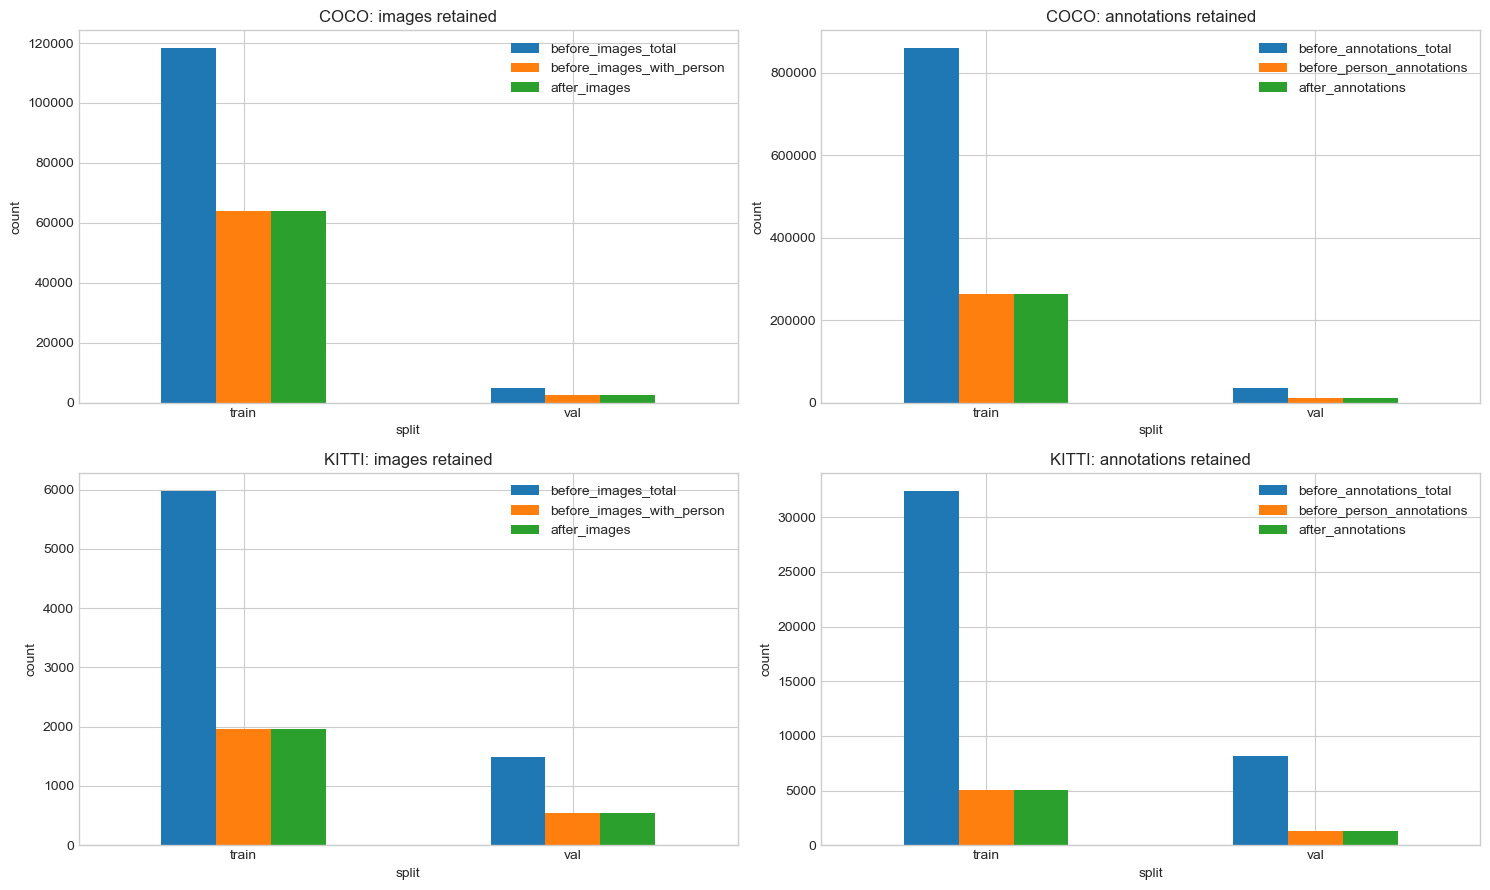

,dataset,split,image_retention_vs_total,image_retention_vs_person_images,annotation_retention_vs_total,annotation_retention_vs_person_annotations
0,COCO,train,0.542,1.000,0.305,1.000
1,COCO,val,0.539,1.000,0.299,1.000
2,KITTI,train,0.328,1.000,0.155,1.000
3,KITTI,val,0.358,1.000,0.161,1.000


In [5]:
coco_retention_rows = []
for before_split, after_split in [('train', 'train'), ('validation', 'val')]:
    before_row = coco_before_summary[coco_before_summary['split'] == before_split].iloc[0]
    after_row = coco_after_summary[coco_after_summary['split'] == after_split].iloc[0]
    coco_retention_rows.append({
        'dataset': 'COCO',
        'split': split_key(before_split),
        'before_images_total': int(before_row['num_images']),
        'before_images_with_person': int(before_row['images_with_person']),
        'after_images': int(after_row['num_images']),
        'before_annotations_total': int(before_row['num_annotations']),
        'before_person_annotations': int(before_row['person_annotations']),
        'after_annotations': int(after_row['num_annotations']),
        'image_retention_vs_total': safe_div(int(after_row['num_images']), int(before_row['num_images'])),
        'image_retention_vs_person_images': safe_div(int(after_row['num_images']), int(before_row['images_with_person'])),
        'annotation_retention_vs_total': safe_div(int(after_row['num_annotations']), int(before_row['num_annotations'])),
        'annotation_retention_vs_person_annotations': safe_div(int(after_row['num_annotations']), int(before_row['person_annotations'])),
    })
coco_retention = pd.DataFrame(coco_retention_rows)

kitti_retention_rows = []
for split in ['train', 'val']:
    before_row = kitti_before_summary[kitti_before_summary['split'] == split].iloc[0]
    after_row = kitti_after_summary[kitti_after_summary['split'] == split].iloc[0]
    kitti_retention_rows.append({
        'dataset': 'KITTI',
        'split': split,
        'before_images_total': int(before_row['num_images']),
        'before_images_with_person': int(before_row['images_with_person_like']),
        'after_images': int(after_row['num_images']),
        'before_annotations_total': int(before_row['num_annotations']),
        'before_person_annotations': int(before_row['person_like_annotations']),
        'after_annotations': int(after_row['num_annotations']),
        'image_retention_vs_total': safe_div(int(after_row['num_images']), int(before_row['num_images'])),
        'image_retention_vs_person_images': safe_div(int(after_row['num_images']), int(before_row['images_with_person_like'])),
        'annotation_retention_vs_total': safe_div(int(after_row['num_annotations']), int(before_row['num_annotations'])),
        'annotation_retention_vs_person_annotations': safe_div(int(after_row['num_annotations']), int(before_row['person_like_annotations'])),
    })
kitti_retention = pd.DataFrame(kitti_retention_rows)

retention = pd.concat([coco_retention, kitti_retention], ignore_index=True)
display(retention)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for row_idx, (name, df) in enumerate([('COCO', coco_retention), ('KITTI', kitti_retention)]):
    plot_df = df.set_index('split')
    plot_df[['before_images_total', 'before_images_with_person', 'after_images']].plot(kind='bar', ax=axes[row_idx, 0])
    axes[row_idx, 0].set_title(f'{name}: images retained')
    axes[row_idx, 0].set_ylabel('count')
    axes[row_idx, 0].tick_params(axis='x', rotation=0)

    plot_df[['before_annotations_total', 'before_person_annotations', 'after_annotations']].plot(kind='bar', ax=axes[row_idx, 1])
    axes[row_idx, 1].set_title(f'{name}: annotations retained')
    axes[row_idx, 1].set_ylabel('count')
    axes[row_idx, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

rate_cols = [
    'image_retention_vs_total',
    'image_retention_vs_person_images',
    'annotation_retention_vs_total',
    'annotation_retention_vs_person_annotations',
]
display(
    retention[['dataset', 'split'] + rate_cols].style.format(
        {column: '{:.3f}' for column in rate_cols},
        na_rep='-',
    )
)


## Distribution Checks

This section keeps the broad class-distribution sanity checks from the original EDA and adds one compact geometry summary for before/after person boxes.

### COCO origin top classes

,category_id,category_name,count
0,1,person,262465
1,3,car,43867
2,62,chair,38491
3,84,book,24715
4,44,bottle,24342
5,47,cup,20650
6,67,dining table,15714
7,51,bowl,14358
8,10,traffic light,12884
9,31,handbag,12354


,category_id,category_name,count
0,1,person,11004
1,3,car,1932
2,62,chair,1791
3,84,book,1161
4,44,bottle,1025
5,47,cup,899
6,67,dining table,697
7,10,traffic light,637
8,51,bowl,626
9,31,handbag,540


### KITTI origin class counts

,class_id,class_name,count
0,0,car,28742
3,3,pedestrian,4487
1,1,van,2914
5,5,cyclist,1627
2,2,truck,1094
7,7,misc,973
6,6,tram,511
4,4,Person_sitting,222


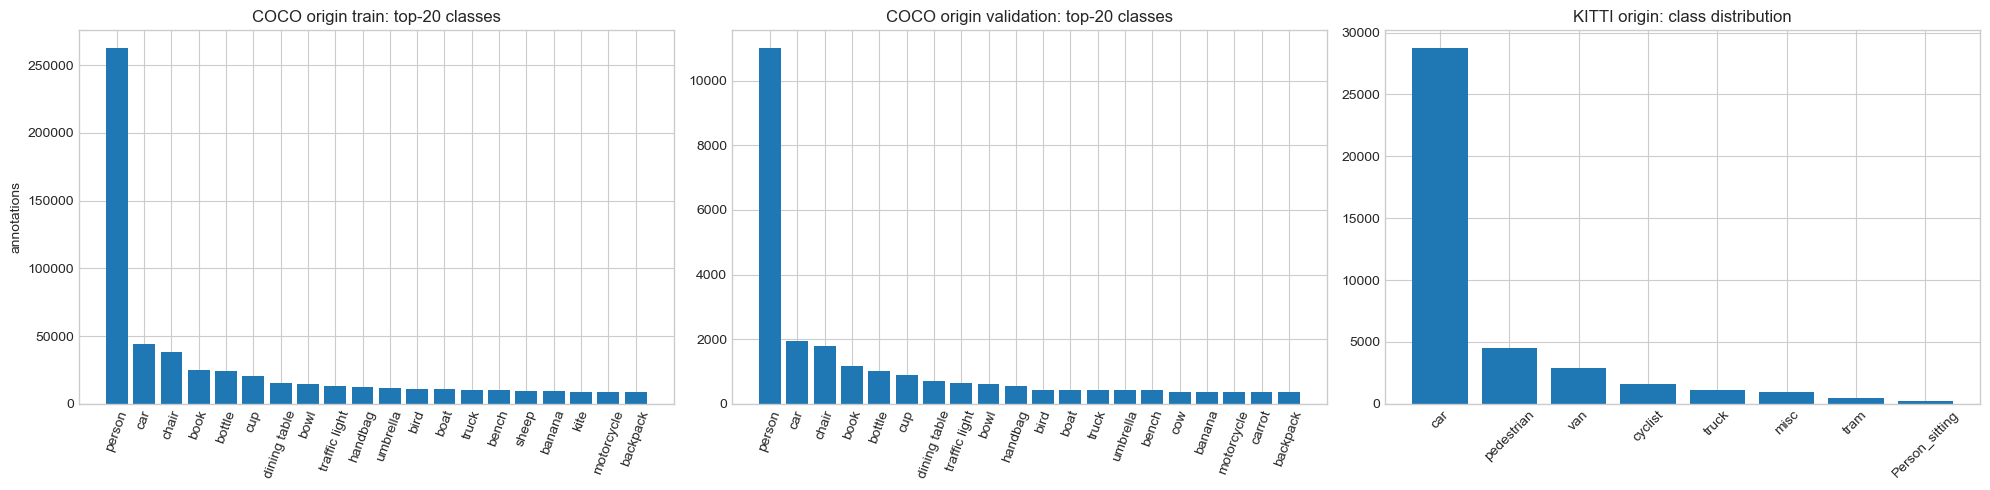

### Person-box geometry summary

area_ratio         aspect_ratio        
                   median    mean       median    mean
dataset stage                                         
COCO    after      0.0069  0.0406       0.5469  0.7027
        before     0.0069  0.0406       0.5469  0.7027
KITTI   after      0.0060  0.0139       0.4174  0.4888
        before     0.0060  0.0139       0.1261  0.1477

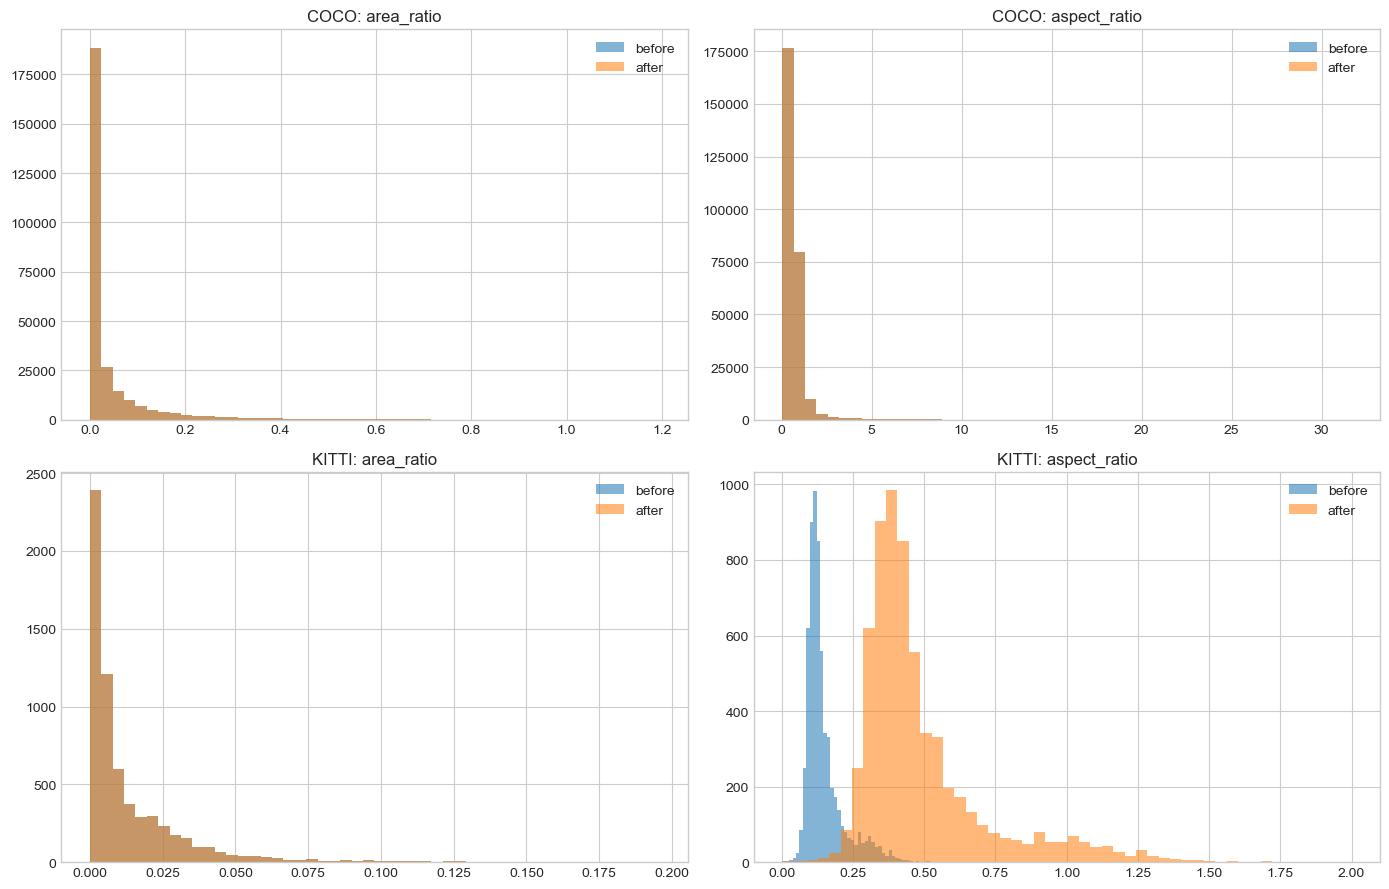

In [6]:
origin_train_class_counts = coco_class_counts(coco_origin['train']).head(20)
origin_val_class_counts = coco_class_counts(coco_origin['validation']).head(20)
kitti_class_counts = (
    kitti_before_df.groupby(['class_id', 'class_name'], as_index=False)
    .size()
    .rename(columns={'size': 'count'})
    .sort_values('count', ascending=False)
)

display(Markdown('### COCO origin top classes'))
display(origin_train_class_counts)
display(origin_val_class_counts)
display(Markdown('### KITTI origin class counts'))
display(kitti_class_counts)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
axes[0].bar(origin_train_class_counts['category_name'], origin_train_class_counts['count'])
axes[0].set_title('COCO origin train: top-20 classes')
axes[0].set_ylabel('annotations')
axes[0].tick_params(axis='x', rotation=70)

axes[1].bar(origin_val_class_counts['category_name'], origin_val_class_counts['count'])
axes[1].set_title('COCO origin validation: top-20 classes')
axes[1].tick_params(axis='x', rotation=70)

axes[2].bar(kitti_class_counts['class_name'], kitti_class_counts['count'])
axes[2].set_title('KITTI origin: class distribution')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

coco_before_person = pd.concat([
    coco_annotations_df(
        coco_origin[split],
        'COCO',
        split_key(split),
        ann_filter=lambda ann, ids=coco_person_ids(coco_origin[split]): ann.get('category_id') in ids,
    )
    for split in ['train', 'validation']
], ignore_index=True)
coco_before_person['stage'] = 'before'

coco_after_person = pd.concat([
    coco_annotations_df(
        coco_filtered[split],
        'COCO',
        split_key(split),
        ann_filter=lambda ann, ids=coco_person_ids(coco_filtered[split]): ann.get('category_id') in ids,
    )
    for split in ['train', 'val']
], ignore_index=True)
coco_after_person['stage'] = 'after'

kitti_before_person = kitti_before_df[kitti_before_df['is_person_like']].copy()
kitti_before_person['dataset'] = 'KITTI'
kitti_before_person['stage'] = 'before'
kitti_before_person['bbox_w'] = kitti_before_person['bbox_w_norm']
kitti_before_person['bbox_h'] = kitti_before_person['bbox_h_norm']
kitti_before_person['bbox_area'] = kitti_before_person['area_ratio']

kitti_after_person = pd.concat([
    coco_annotations_df(
        kitti_after[split],
        'KITTI',
        split,
        ann_filter=lambda ann, ids=coco_person_ids(kitti_after[split]): ann.get('category_id') in ids,
    )
    for split in ['train', 'val']
], ignore_index=True)
kitti_after_person['stage'] = 'after'

geometry = pd.concat([
    coco_before_person[['dataset', 'stage', 'area_ratio', 'aspect_ratio']].copy(),
    coco_after_person[['dataset', 'stage', 'area_ratio', 'aspect_ratio']].copy(),
    kitti_before_person[['dataset', 'stage', 'area_ratio', 'aspect_ratio']].copy(),
    kitti_after_person[['dataset', 'stage', 'area_ratio', 'aspect_ratio']].copy(),
], ignore_index=True)

geometry_summary = (
    geometry.groupby(['dataset', 'stage'])[['area_ratio', 'aspect_ratio']]
    .agg(['median', 'mean'])
    .round(4)
)
display(Markdown('### Person-box geometry summary'))
display(geometry_summary)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row_idx, dataset_name in enumerate(['COCO', 'KITTI']):
    subset = geometry[geometry['dataset'] == dataset_name]
    for col_idx, metric in enumerate(['area_ratio', 'aspect_ratio']):
        ax = axes[row_idx, col_idx]
        before_vals = subset[subset['stage'] == 'before'][metric].dropna()
        after_vals = subset[subset['stage'] == 'after'][metric].dropna()
        ax.hist(before_vals, bins=50, alpha=0.55, label='before')
        ax.hist(after_vals, bins=50, alpha=0.55, label='after')
        ax.set_title(f'{dataset_name}: {metric}')
        ax.legend()
plt.tight_layout()
plt.show()


## KITTI Strict Same-Stem Validation

This is the visual alignment check

`shared_stems` is either the manual list you provide in `MANUAL_STEMS` or a reproducible random sample from the common origin/filtered train stems.

In [9]:
ORIGIN_TRAIN_IMAGES = KITTI_YOLO_ROOT / 'images' / 'train'
ORIGIN_TRAIN_LABELS = KITTI_YOLO_ROOT / 'labels' / 'train'
FILTERED_TRAIN_ANN = KITTI_FILTERED_ROOT / 'annotations' / 'instances_train.json'

filtered_image_paths, filtered_boxes = load_filtered_index(FILTERED_TRAIN_ANN, KITTI_FILTERED_ROOT, person_cat_id=1)
origin_person_like_stems = collect_origin_stems_with_class(ORIGIN_TRAIN_LABELS, PERSON_LIKE_IDS)
filtered_person_stems = {stem for stem, boxes in filtered_boxes.items() if boxes}
common_stems = sorted(origin_person_like_stems & filtered_person_stems)

if not common_stems:
    raise RuntimeError('No common stems found between origin person-like labels and filtered person labels.')

shared_stems = list(MANUAL_STEMS) if MANUAL_STEMS else random.Random(SAMPLE_SEED).sample(common_stems, k=min(N_SAMPLES, len(common_stems)))

for stem in shared_stems:
    assert (ORIGIN_TRAIN_LABELS / f'{stem}.txt').exists(), f'Missing origin label for {stem}'
    assert find_image_for_stem(ORIGIN_TRAIN_IMAGES, stem) is not None, f'Missing origin image for {stem}'
    assert filtered_boxes.get(stem), f'Missing filtered person boxes for {stem}'
    assert filtered_image_paths.get(stem) is not None and filtered_image_paths[stem].exists(), f'Missing filtered image for {stem}'

strict_summary = pd.DataFrame([
    {
        'origin_person_like_stems': len(origin_person_like_stems),
        'filtered_person_stems': len(filtered_person_stems),
        'common_stems': len(common_stems),
        'sample_size': len(shared_stems),
        'sample_seed': SAMPLE_SEED,
    }
])

display(strict_summary)
print('shared_stems:', shared_stems)


,origin_person_like_stems,filtered_person_stems,common_stems,sample_size,sample_seed
0,1965,1965,1965,6,11


shared_stems: ['003373', '006750', '004235', '006649', '007202', '006065']


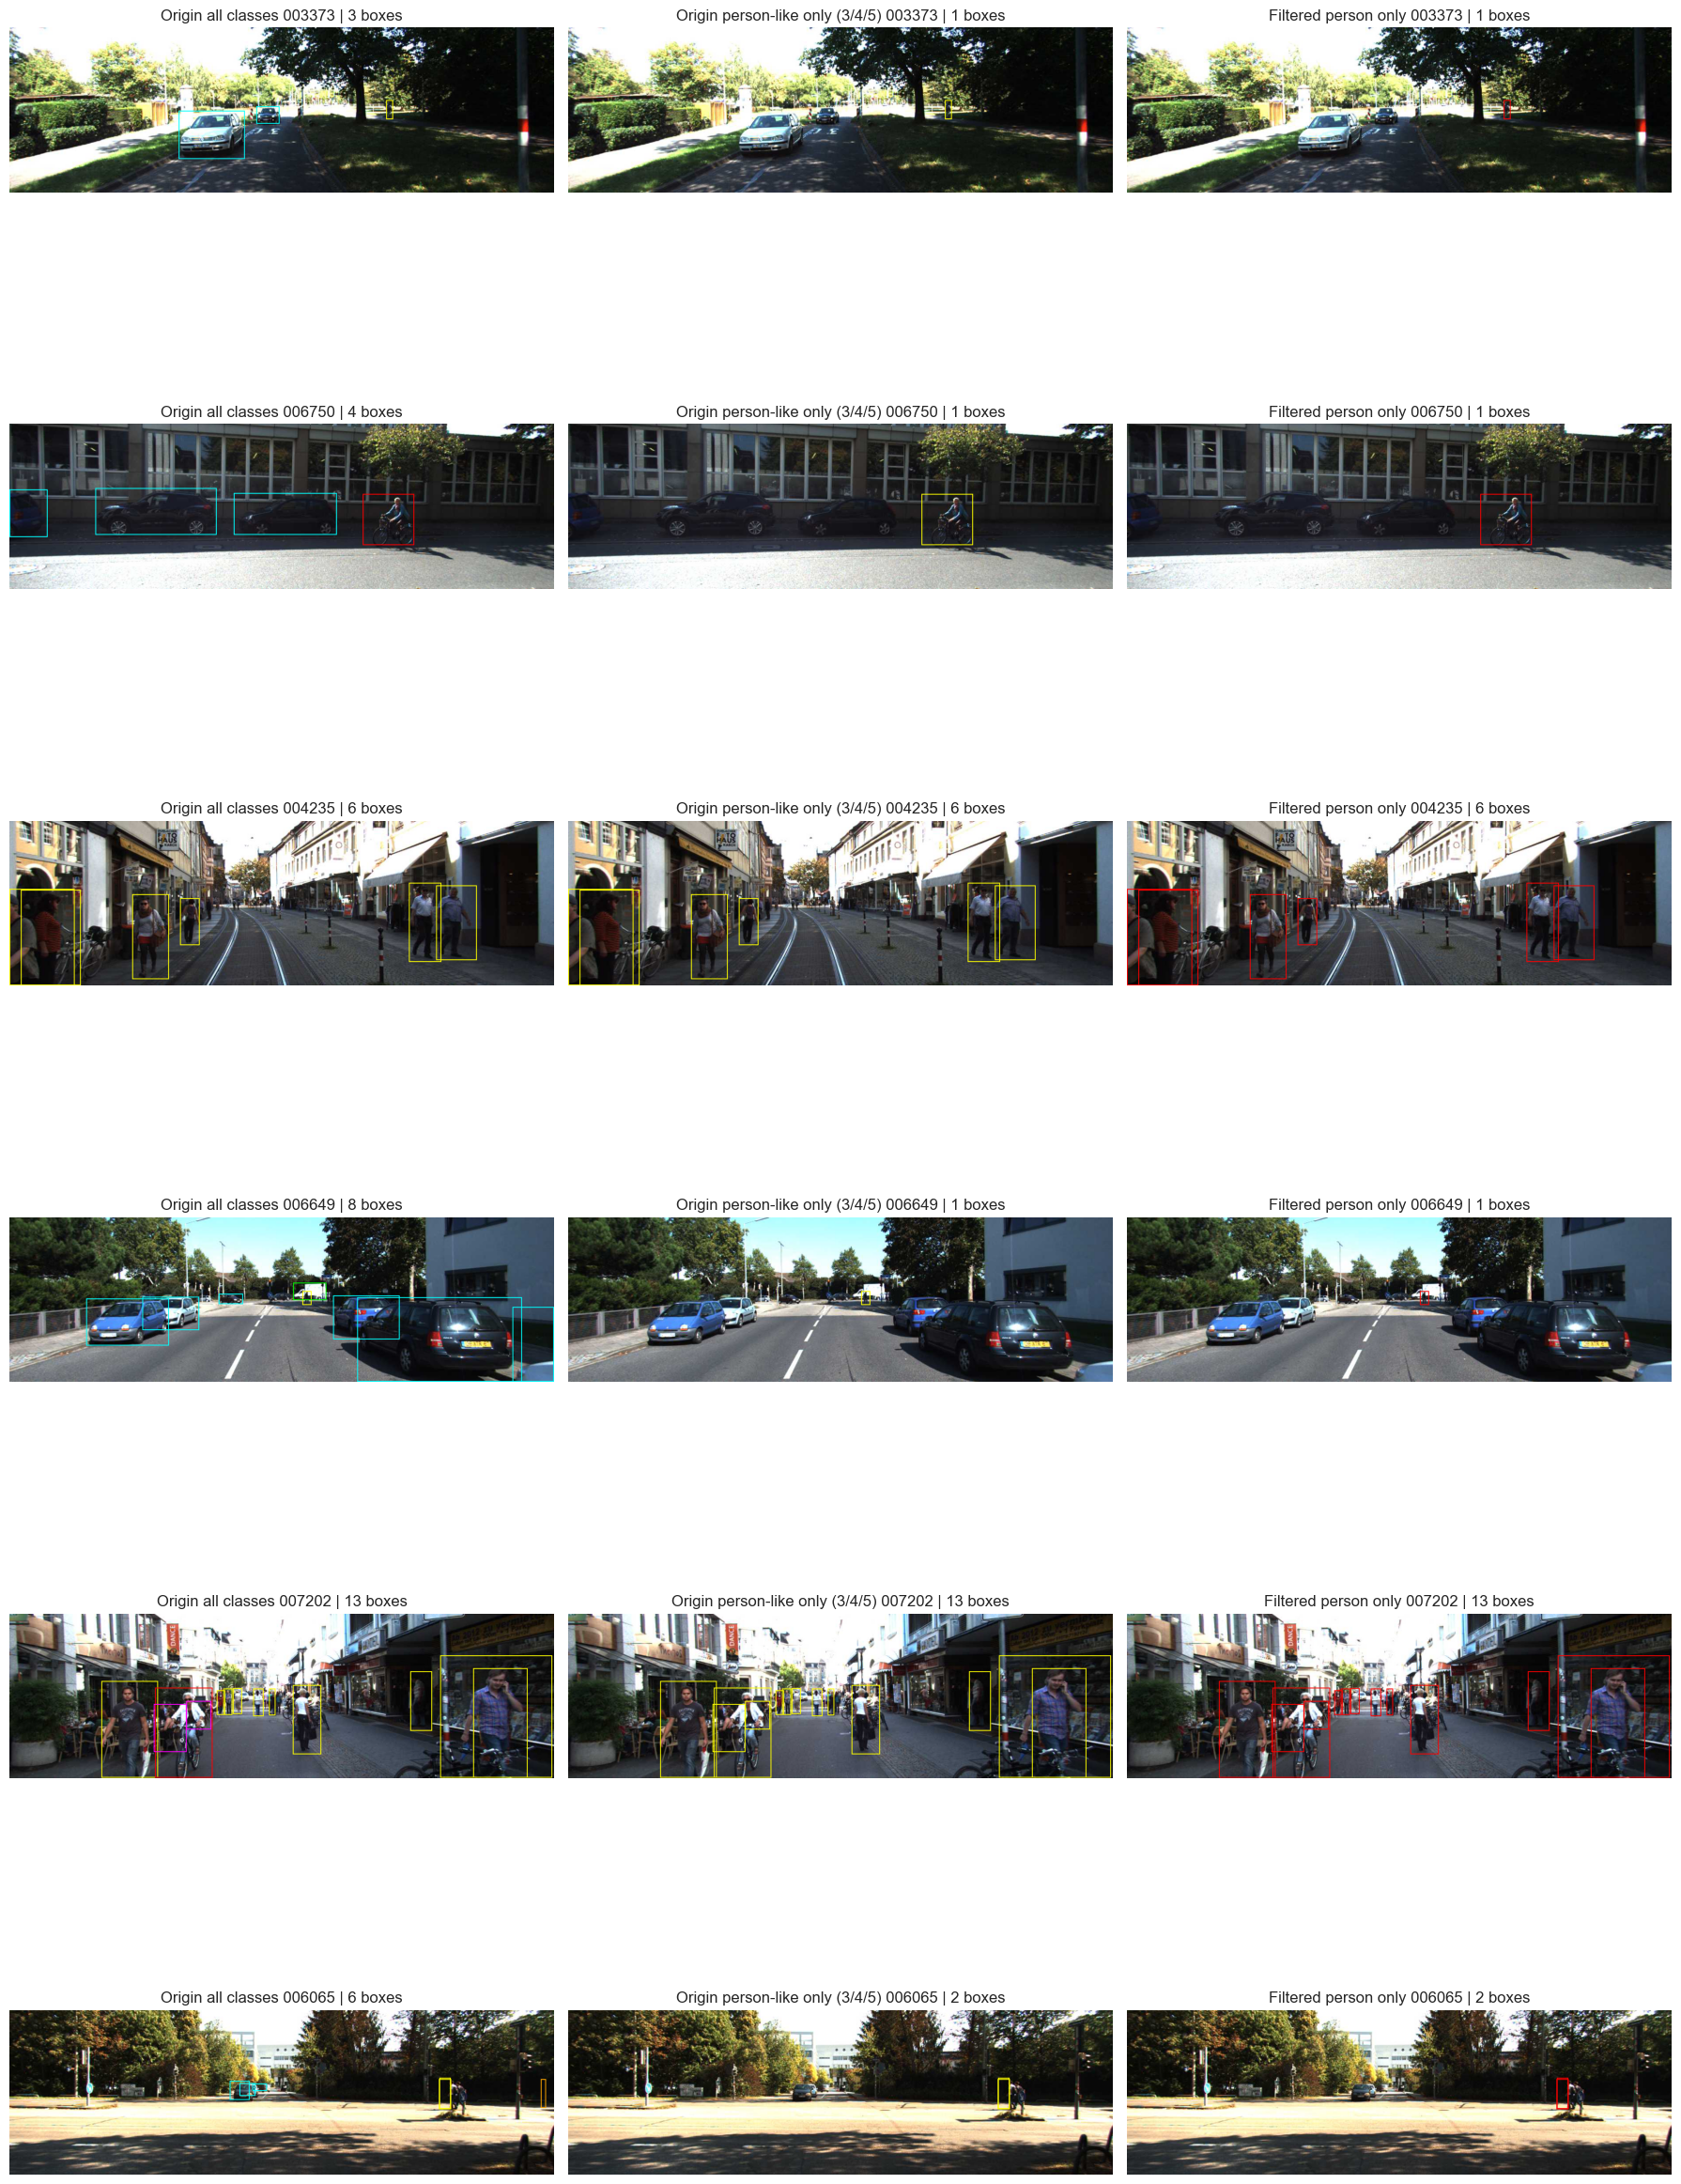

In [8]:
plot_strict_matrix(
    shared_stems,
    origin_images_dir=ORIGIN_TRAIN_IMAGES,
    origin_labels_dir=ORIGIN_TRAIN_LABELS,
    filtered_paths=filtered_image_paths,
    filtered_boxes=filtered_boxes,
)


## Notes

- COCO origin test has no annotations, so person-retention comparisons are limited to train and validation.
- KITTI `person-like` refers to class IDs `{3, 4, 5}`: `pedestrian`, `Person_sitting`, and `cyclist`.
- The KITTI geometry comparison uses normalized YOLO box width/height before filtering, so `area_ratio` remains comparable across before/after even though the annotation formats differ.
- To inspect specific KITTI stems, set `MANUAL_STEMS = ['000005', '000007', ...]` and rerun the final two cells.
